In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# import dataset & check the 5 first data
df = pd.read_csv('ecommerce.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


In [5]:
df['Sales'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom,2.55


In [6]:
# check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
 8   Sales        4870 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 342.6+ KB


In [7]:
rows = df.shape[0]
columns = df.shape[1]

print(f'Number of rows: {rows}')
print(f'Number of columns: {columns}')

Number of rows: 4870
Number of columns: 9


In [8]:
# check duplicate data
df.duplicated().sum()

np.int64(0)

In [9]:
# Turn InvoiceDate column data type into datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate']

,InvoiceDate
0,2011-05-25 17:31:00
1,2011-07-24 11:58:00
2,2011-07-19 12:54:00
3,2011-07-13 11:34:00
4,2011-02-20 12:23:00
...,...
4865,2011-10-19 13:58:00
4866,2011-03-03 13:45:00
4867,2011-01-07 12:28:00
4868,2011-11-03 15:16:00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4870 non-null   int64         
 1   StockCode    4870 non-null   object        
 2   Description  4870 non-null   object        
 3   Quantity     4870 non-null   int64         
 4   InvoiceDate  4870 non-null   datetime64[ns]
 5   UnitPrice    4870 non-null   float64       
 6   CustomerID   4870 non-null   int64         
 7   Country      4870 non-null   object        
 8   Sales        4870 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 342.6+ KB


In [11]:
# Show total unique value in each columns
df.nunique()

,0
InvoiceNo,3804
StockCode,1773
Description,1807
Quantity,68
InvoiceDate,3757
UnitPrice,118
CustomerID,1932
Country,31
Sales,611


## Exploratory Questions:
1. How is Data Distribution in Unit Price, Quantity, and Sales data?
2. Is there any outliers in Unit Price, Quantity, and Sales data? if yes, point out the middle data and the outliers.
3. How much the percentage of the outliers of Unit Price, Quantity, and Sales data?
4. Is there any correlation between Unit Price, Quantity, and Sales?
5. How strong is the correlation between Unit Price, Quantity, and Sales?

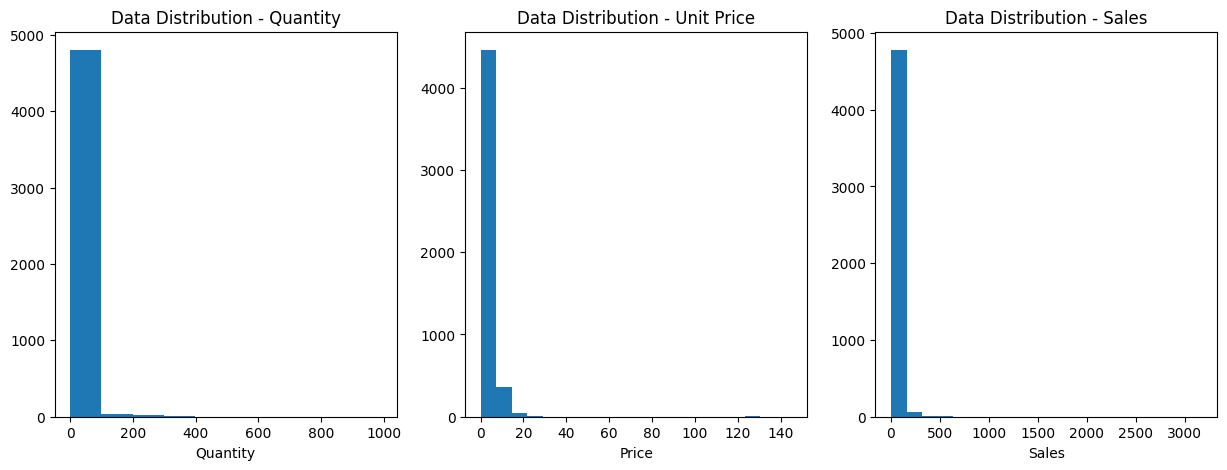

In [12]:
# Check the data distributions of Quantity and Unit Price
fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].hist(df['Quantity'], bins=10)
axes[0].set_title('Data Distribution - Quantity')
axes[0].set_xlabel('Quantity')

axes[1].hist(df['UnitPrice'], bins=20)
axes[1].set_title('Data Distribution - Unit Price')
axes[1].set_xlabel('Price')

axes[2].hist(df['Sales'], bins=20)
axes[2].set_title('Data Distribution - Sales')
axes[2].set_xlabel('Sales')

plt.show()

**Answer 1:**

The data distribution shown that all historical charts are heavily skewed towards right. The data is centered on the low purchase with cheaper price yet the frequency of the transactions are quite often.

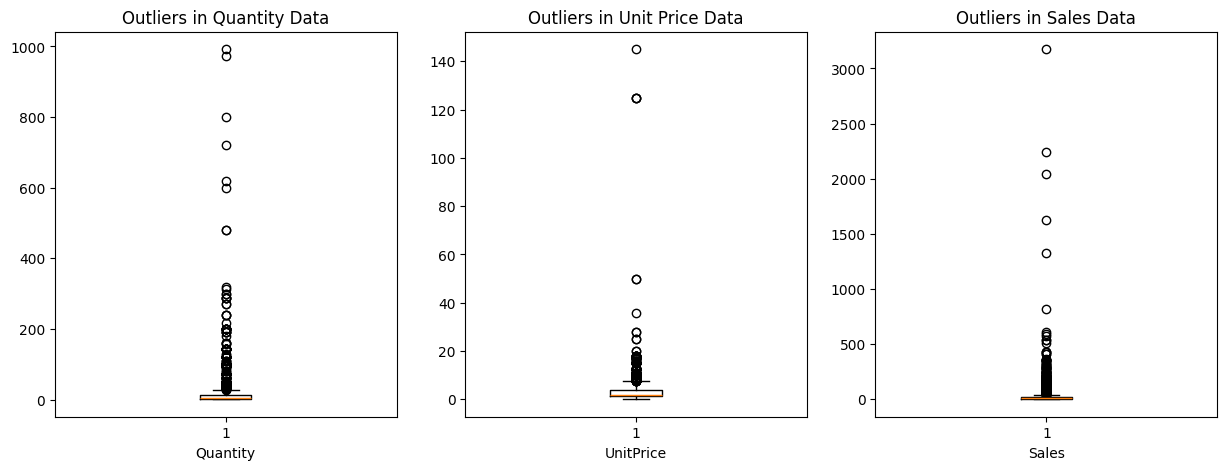

In [13]:
# check the comparison of data distribution between quantity and unite price using boxplot
fig, axes = plt.subplots(1,3,figsize=(15,5))

axes[0].boxplot(df['Quantity'])
axes[0].set_xlabel('Quantity')
axes[0].set_title('Outliers in Quantity Data')

axes[1].boxplot(df['UnitPrice'])
axes[1].set_xlabel('UnitPrice')
axes[1].set_title('Outliers in Unit Price Data')

axes[2].boxplot(df['Sales'])
axes[2].set_xlabel('Sales')
axes[2].set_title('Outliers in Sales Data')

plt.show()


**Answer 2:**

There are outliers shown in Quantity, Unit Price, and Sales data. The purpose is to show whether the data has outliers or not. If yes, whether the numbers are significant or relatively small.

In [14]:
# Check the outlier of unit price
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
range = df['UnitPrice'].max() - df['UnitPrice'].min()

IQR = Q3 - Q1

lower_line = Q1 - (IQR * 1.5)
upper_line = Q3 + (IQR * 1.5)

print('Mean vs Median Comparison (Middle Data):')
print('- Mean:', df['UnitPrice'].mean())
print('- Median:', df['UnitPrice'].median())
print('')
print('Data Distribution of Unit Price:')
print('- Std Price:', df['UnitPrice'].std())
print(f'- IQR Price: {IQR}')
print(f'- Lower Line: {lower_line}')
print(f'- Upper Line: {upper_line}')
print(f'- Range Price: {range}')

Mean vs Median Comparison (Middle Data):
- Mean: 2.9370574948665302
- Median: 1.95

Data Distribution of Unit Price:
- Std Price: 4.744514674613008
- IQR Price: 2.5
- Lower Line: -2.5
- Upper Line: 7.5
- Range Price: 144.96


In [15]:
price_outliers = df[(df['UnitPrice'] < lower_line) | (df['UnitPrice'] > upper_line)]
price_outliers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
9,562888,22485,SET OF 2 WOODEN MARKET CRATES,2,2011-08-10 11:58:00,12.75,14388,United Kingdom,25.5
11,551983,22485,SET OF 2 WOODEN MARKET CRATES,2,2011-05-05 14:32:00,12.75,17735,United Kingdom,25.5
35,559109,22844,VINTAGE CREAM DOG FOOD CONTAINER,1,2011-07-06 11:52:00,8.50,15021,United Kingdom,8.5
43,543911,48138,DOORMAT UNION FLAG,2,2011-02-14 12:46:00,7.95,17829,United Arab Emirates,15.9
55,569524,48188,DOORMAT WELCOME PUPPIES,2,2011-10-04 14:42:00,8.25,14506,United Kingdom,16.5


In [42]:
# Check the outlier of quantity
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
range = df['Quantity'].max() - df['Quantity'].min()

IQR = Q3 - Q1

lower_line = Q1 - (IQR * 1.5)
upper_line = Q3 + (IQR * 1.5)

print('Mean vs Median Comparison (Middle Data):')
print('- Mean:', df['Quantity'].mean())
print('- Median:', df['Quantity'].median())
print('')
print('Data Distribution of Product Quantities:')
print('- Std Quantity:', df['Quantity'].std())
print(f'- IQR Quantity: {IQR}')
print(f'- Lower Line: {lower_line}')
print(f'- Upper Line: {upper_line}')
print(f'- Range Quantity: {range}')

Mean vs Median Comparison (Middle Data):
- Mean: 12.945790554414785
- Median: 5.0

Data Distribution of Product Quantities:
- Std Quantity: 38.14598782418509
- IQR Quantity: 10.0
- Lower Line: -13.0
- Upper Line: 27.0
- Range Quantity: 991


In [17]:
qty_outliers = df[(df['Quantity'] < lower_line) | (df['Quantity'] > upper_line)]
qty_outliers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
17,569640,23197,SKETCHBOOK MAGNETIC SHOPPING LIST,36,2011-10-05 12:25:00,1.45,12471,Germany,52.20
73,566987,22556,PLASTERS IN TIN CIRCUS PARADE,36,2011-09-16 10:56:00,1.65,12476,Germany,59.40
89,577857,21822,GLITTER CHRISTMAS TREE WITH BELLS,36,2011-11-22 11:21:00,0.79,13499,United Kingdom,28.44
96,578140,47591D,PINK FAIRY CAKE CHILDRENS APRON,50,2011-11-23 10:58:00,1.65,14646,Netherlands,82.50
99,578517,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,48,2011-11-24 13:53:00,0.29,16523,United Kingdom,13.92


In [44]:
# Check the outlier of sales
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
range = df['Sales'].max() - df['Sales'].min()

IQR = Q3 - Q1

lower_line = Q1 - (IQR * 1.5)
upper_line = Q3 + (IQR * 1.5)

print('Mean vs Median Comparison (Middle Data):')
print('- Mean:', df['Sales'].mean())
print('- Median:', df['Sales'].median())
print('')
print('Data Distribution of Items Sold:')
print('- Std Sales:', df['Sales'].std())
print(f'- IQR Sales: {IQR}')
print(f'- Lower Line: {lower_line}')
print(f'- Upper Line: {upper_line}')
print(f'- Range Sales: {range}')

Mean vs Median Comparison (Middle Data):
- Mean: 22.952753593429158
- Median: 11.399999999999999

Data Distribution of Items Sold:
- Std Sales: 81.4088597754778
- IQR Sales: 15.549999999999997
- Lower Line: -19.074999999999996
- Upper Line: 43.12499999999999
- Range Sales: 3174.28


In [19]:
sales_outliers = df[(df['Sales'] < lower_line) | (df['Sales'] > upper_line)]
sales_outliers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
17,569640,23197,SKETCHBOOK MAGNETIC SHOPPING LIST,36,2011-10-05 12:25:00,1.45,12471,Germany,52.20
29,561875,23311,VINTAGE CHRISTMAS STOCKING,24,2011-07-31 12:05:00,2.55,14885,United Kingdom,61.20
56,537236,21531,RED RETROSPOT SUGAR JAM BOWL,24,2010-12-06 09:52:00,2.10,16858,United Kingdom,50.40
64,547716,22084,PAPER CHAIN KIT EMPIRE,15,2011-03-25 08:52:00,2.95,16833,United Kingdom,44.25
67,562393,23154,SET OF 4 JAM JAR MAGNETS,24,2011-08-04 16:17:00,2.08,18172,United Kingdom,49.92


In [45]:
price_percent = (len(price_outliers) / len(df)) * 100
qty_percent = (len(qty_outliers) / len(df)) * 100
sales_percent = (len(sales_outliers) / len(df)) * 100

print(f'The percentage of outliers in unit price: {price_percent:.2f}')
print(f'The percentage of outliers in product quantities: {qty_percent:.2f}')
print(f'The percentage of outliers in sales: {sales_percent:.2f}')

The percentage of outliers in unit price: 8.34
The percentage of outliers in product quantities: 6.74
The percentage of outliers in sales: 8.28


Overall, outliers in the unit price, quantity, and sales data do not exceed 10% of the total data. The outliers are kept because the amounts are still tolerable and will not make the data less accurate.

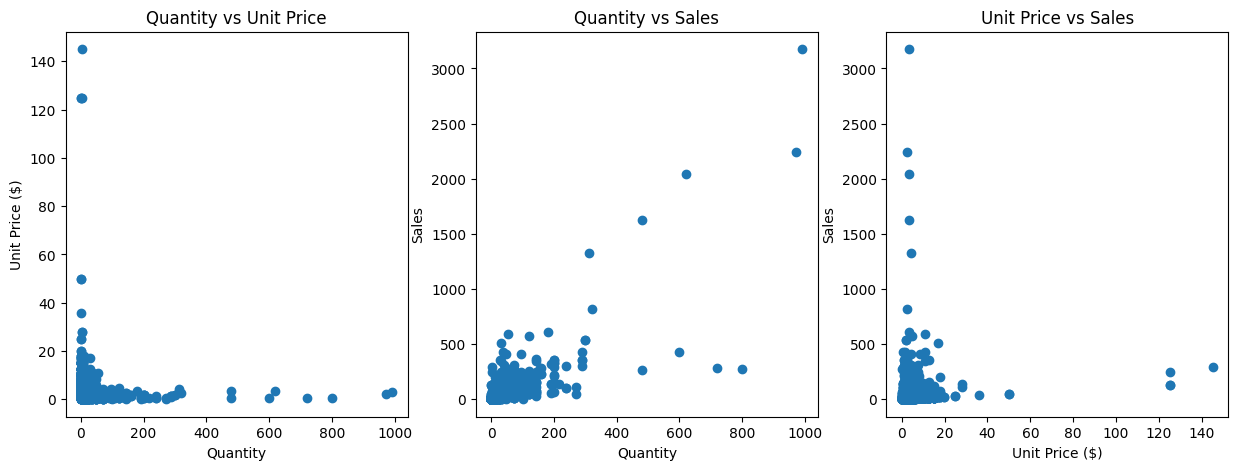

In [46]:
fig, axes = plt.subplots(1,3,figsize=(15, 5))

axes[0].scatter(data=df, x = 'Quantity', y = 'UnitPrice')
axes[0].set_title('Quantity vs Unit Price')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Unit Price ($)')

axes[1].scatter(data=df, x = 'Quantity', y = 'Sales')
axes[1].set_title('Quantity vs Sales')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Sales')

axes[2].scatter(data=df, x = 'UnitPrice', y = 'Sales')
axes[2].set_title('Unit Price vs Sales')
axes[2].set_xlabel('Unit Price ($)')
axes[2].set_ylabel('Sales')

plt.show()

**Answer 4:**

Based on pattern from the scatterplot graphs:
1. The pattern between Unit Price and Quantity is hard to recognise, so possibly there's no correlation between them.
2. There is a positive correlation between Sales and Quantity where the higher numbers of products being purchased, the higher amount sales were made.
3. The pattern between Unit Price and Sales is hard to recognise, so possibly there's no correlation between them.

The purpose is to know the correlation between two data.


In [22]:
correlations = df[['Quantity', 'UnitPrice', 'Sales']].corr()
correlations

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.083283,0.788586
UnitPrice,-0.083283,1.000000,0.091612
Sales,0.788586,0.091612,1.000000


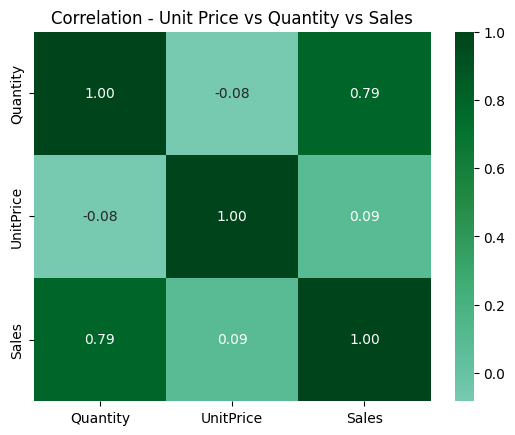

In [23]:
sns.heatmap(
    correlations,
    annot=True,
    cmap='BuGn',
    center=0,
    fmt='.2f'
)

plt.title('Correlation - Unit Price vs Quantity vs Sales')
plt.show()

**Answer 5:**

Based on pattern from the heatmap graph:
1. There is a strong correlation between Sales and Quantity.
2. There is a weak correlation between Unit Price and Quantity.
3. There is a weak correlation between Unit Price and Sales.

The purpose is to know the exact amount and the strength correlation between three data.

## Business Questions:
1. How much the monthly sales that the company made in 2011?
2. How much is the total sales, average sales, and products sold in every countries in 2011? Which countries that dominate the market? (limit to 5)
3. What is the monthly sales in 2011 based on countries with top 5 sales?
4. What kind of products that make the biggest sales? (limit to 5).
5. What are the top 5 popular products in countries that make top 5 sales?




In [24]:
# Change the date format into abbreviation month
df['Month'] = df['InvoiceDate'].dt.strftime('%b')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Month
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2.08,May
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,5.10,Jul
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,1.65,Jul
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,15.00,Jul
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2.55,Feb


In [25]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

In [26]:
# Order months from Jan - Dec
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories = month_order,
    ordered = True
)

monthly_sales = monthly_sales.sort_values('Month')

In [27]:
monthly_sales

,Month,Sales
4,Jan,6247.52
3,Feb,6152.46
7,Mar,7162.64
0,Apr,6357.63
8,May,6987.24
6,Jun,7203.93
5,Jul,7569.27
1,Aug,9904.91
11,Sep,9761.11
10,Oct,10177.38


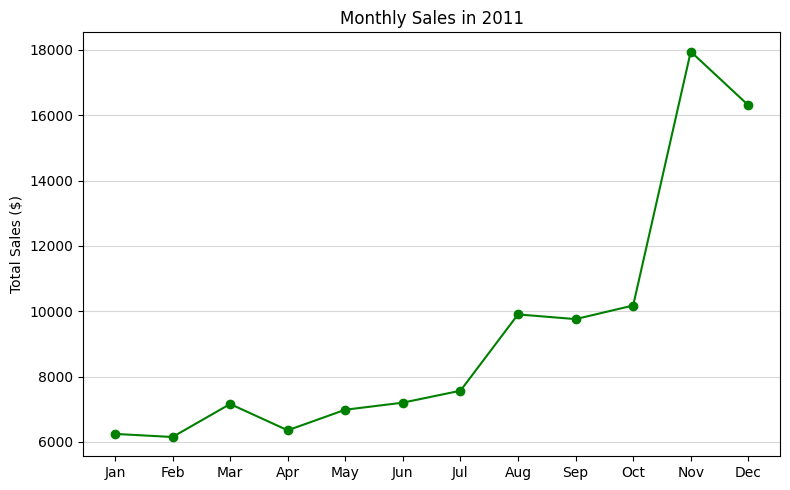

In [50]:
plt.figure(figsize=(8,5))

plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker= 'o', color='green')

plt.title('Monthly Sales in 2011')
plt.ylabel('Total Sales ($)')
plt.grid(axis = 'y', alpha = 0.5)
plt.tight_layout()

plt.show()

**Conclusion 1:**

Generally, in 2011, the company has shown very significant growth. Throughout January until July, mostly the company's sales relatively stable. But started from August, the transactions had skyrocketted from 10,000 USD to near 18,000 USD in  November, and then it decreased slightly to almost 16,000 USD in December, yet, it still considerably high. The increasing numbers in sales might be caused by Summer Holidays and events such as Halloween and Christmas.  

In [29]:
country_table = df.groupby(df['Country']).agg(
    Total_Sales =('Sales','sum'),
    Average_Sales =('Sales','mean'),
    Total_Products =('Quantity','sum')
).sort_values(by= 'Total_Sales', ascending=False)
country_table

,Total_Sales,Average_Sales,Total_Products
Country,,,
United Kingdom,93011.36,21.401601,51694
Netherlands,3622.33,139.320385,2473
Germany,3363.77,27.799752,1742
EIRE,3156.78,35.075333,1588
France,2320.55,26.073596,1299
Sweden,988.74,82.395000,1008
Australia,937.00,72.076923,828
Switzerland,902.52,32.232857,500
Portugal,562.90,35.181250,267


In [30]:
# change country's names into common names
df['Country'] = df['Country'].replace(['EIRE', 'RSA'], ['Ireland', 'South Africa'])
df.query('Country == "Ireland" or Country == "South Africa"')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Month
135,553206,23206,LUNCH BAG APPLE DESIGN,10,2011-05-16 08:16:00,1.65,14156,Ireland,16.50,May
185,576595,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96,2011-11-15 14:56:00,2.55,14911,Ireland,244.80,Nov
211,556510,79321,CHILLI LIGHTS,4,2011-06-13 10:36:00,5.75,14911,Ireland,23.00,Jun
291,575751,21677,HEARTS STICKERS,24,2011-11-11 10:32:00,0.85,14911,Ireland,20.40,Nov
320,563848,23211,RED ROCKING HORSE HAND PAINTED,24,2011-08-19 14:57:00,1.25,14911,Ireland,30.00,Aug
...,...,...,...,...,...,...,...,...,...,...
4735,551657,22501,PICNIC BASKET WICKER LARGE,2,2011-05-03 12:12:00,9.95,14911,Ireland,19.90,May
4757,577850,21986,PACK OF 12 PINK POLKADOT TISSUES,24,2011-11-22 11:04:00,0.39,14911,Ireland,9.36,Nov
4822,577613,21124,SET/10 BLUE POLKADOT PARTY CANDLES,24,2011-11-21 10:02:00,1.25,14911,Ireland,30.00,Nov
4842,576051,21217,RED RETROSPOT ROUND CAKE TINS,6,2011-11-13 14:45:00,9.95,14911,Ireland,59.70,Nov


In [31]:
# countries with top 5 sales
country_table.head(5)

,Total_Sales,Average_Sales,Total_Products
Country,,,
United Kingdom,93011.36,21.401601,51694
Netherlands,3622.33,139.320385,2473
Germany,3363.77,27.799752,1742
EIRE,3156.78,35.075333,1588
France,2320.55,26.073596,1299


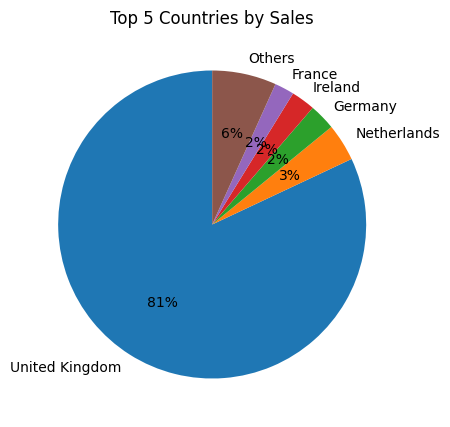

In [32]:
country_sales = df.groupby('Country')['Quantity'].sum().sort_values(ascending=False)

# Choose top 5 countries
top5_sales = country_sales.head(5)

# The rest belong to "Others" category
other_countries = country_sales.iloc[5:].sum()

# Create a Pie Chart
pie_data = pd.concat([top5_sales, pd.Series({'Others': other_countries})])

plt.figure(figsize=(5,5))
plt.pie(
    pie_data.values,
    labels= pie_data.index,
    autopct ="%d%%",
    startangle= 90
)

plt.title('Top 5 Countries by Sales')
plt.show()

**Conclusion 2:**

Countries with top 5 sales are from UK, Netherlands, Germany, Ireland, and France. Generally, they made sales more than 2,000 USD and product quantities sold more than 1,000 pcs, with UK dominating the market. Yet, Netherlands has the highest average amount of sales by 139 USD.

There are 3 possibilities why the market is still centered in the UK:
1. The shipping cost is way cheaper in the UK compared to other nations;
2. Low awareness of e-commerce’s existence in other nations compared to the UK;
3. International customers prefer buying gifts from physical stores rather than from an online store where one have to wait for days/weeks just for the items to be delivered.

In [33]:
# Countries with top 5 sales
top5_countries = (
    df.groupby('Country')['Sales']
    .sum()
    .nlargest(5)
    .index
)
top_countries_df = df[df['Country'].isin(top5_countries)]

In [34]:
# Count Sales from each country
country_monthly_sales = (
    top_countries_df
    .groupby(['Country', 'Month'])['Sales']
    .sum()
    .reset_index()
)

In [35]:
country_monthly_sales['Month'] = pd.Categorical(
    country_monthly_sales['Month'],
    categories = month_order,
    ordered = True
)

country_monthly_sales = country_monthly_sales.sort_values('Month')

In [36]:
# Create pivot table
pivot = country_monthly_sales.pivot(
    index = 'Month',
    columns = 'Country',
    values = 'Sales'
)

pivot

Country,France,Germany,Ireland,Netherlands,United Kingdom
Month,,,,,
Jan,202.21,209.50,87.60,208.32,4772.16
Feb,102.42,213.15,251.17,360.00,4712.69
Mar,160.26,431.82,94.29,105.00,5134.13
Apr,30.60,356.75,60.60,90.00,5589.68
May,68.10,171.45,136.50,365.60,6080.95
Jun,549.90,290.92,92.90,855.75,4993.20
Jul,343.60,171.22,968.30,NaN,5721.22
Aug,60.90,237.89,115.72,697.00,8277.62
Sep,265.65,224.98,110.86,580.00,8364.72


<Figure size 2000x800 with 0 Axes>

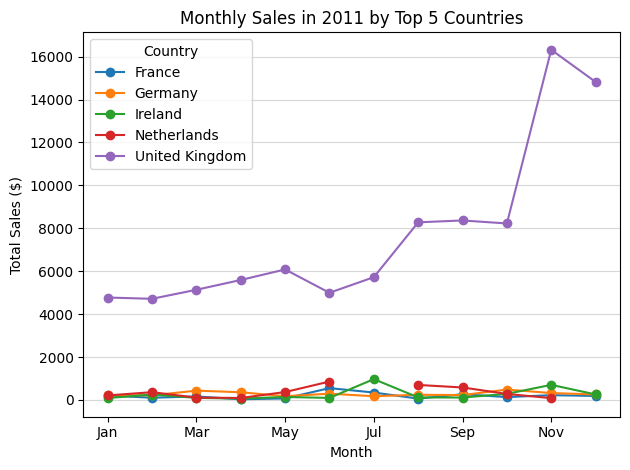

In [49]:
# Plot multilines chart
plt.figure(figsize=(20,8))

pivot.plot(
    kind ='line',
    marker = 'o',
)

plt.title('Monthly Sales in 2011 by Top 5 Countries')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.legend(title='Country')
plt.grid(axis = 'y', alpha = 0.5)
plt.tight_layout()

plt.show()

**Conclusion 3:**

Among top 5 countries with the highest Sales, UK shows robust performance which reaches the peak during November and it falls during June. Netherlands has no sales on July and December, unlike Ireland which shows best performance on July. On the other hand, Germany and France's sales mostly stable throughout the months.

Unlike the other countries, during holidays, Dutch people tend to spend time offline with their families, friends, and loved ones, and it reflected from the government's policy where no business open besides offline retails during Summer Holiday in July and Winter Holiday in December, therefore the company made no sales in those respective months.   

In [38]:
#Create aggregration table
a = df.groupby('Description').agg(
    Total_Products = ('Quantity', 'sum'),
    Total_Sales = ('Sales', 'sum')
).sort_values(by= 'Total_Sales', ascending=False)

# Show top 5 products
a.head(5)

,Total_Products,Total_Sales
Description,,
WHITE HANGING HEART T-LIGHT HOLDER,1291,3979.65
CREAM HEART CARD HOLDER,1032,2462.16
SWEETHEART BIRD HOUSE,621,2050.15
BLACK RECORD COVER FRAME,536,1819.92
JUMBO BAG RED RETROSPOT,783,1396.30


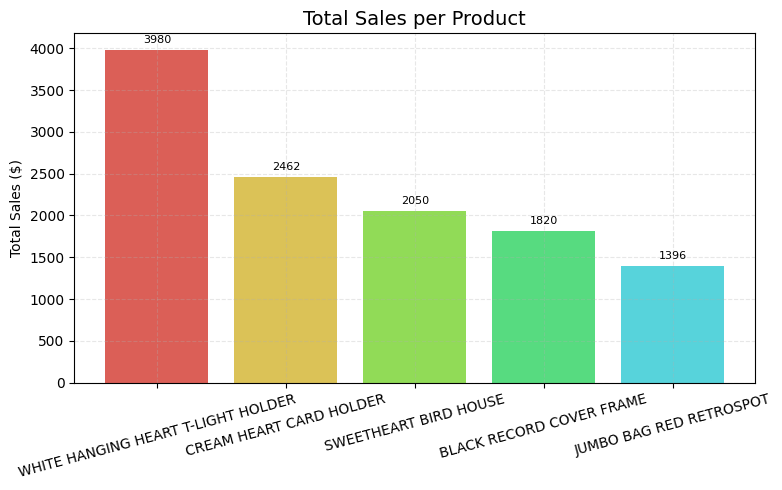

In [51]:
product_sold = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
top5_products = product_sold.head(5)

# Create bar charts
fig, ax = plt.subplots(
    figsize = (8, 5)
)

bars = ax.bar(
    top5_products.index, #utk mengambil nama kategori product sbg sumbu x
    top5_products.values, #utk mengambil nilai product sbg sumbu y
    color = sns.color_palette("hls", 8)
)

ax.set_title("Total Sales per Product", fontsize= 14)
ax.grid(
    axis = 'both',
    alpha = 0.3,
    linestyle = '--'
)
ax.set_ylabel('Total Sales ($)')

for bar in bars:
  tinggi_bar = bar.get_height()
  ax.annotate(
      f'{tinggi_bar:.0f}',
      xy = (bar.get_x() + bar.get_width() /2, tinggi_bar),
      xytext = (0,5),
      textcoords= 'offset points',
      ha = 'center',
      fontsize = 8
  )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Conclusion 4:**

Among the 5 products that generated the most sales are shown by the tables above, the ***White Hanging Heart T-Light Holder*** is the most popular one which made 3,979.65 USD in sales and 1,291 in purchase orders. This T-Light Holder is a unique and thoughtful decoration for special occasions such as tea parties, wedding parties, anniversary celebrations, romantic dinners, or simply for room accessories. Since it is commonly use for events, there is high chance customers purchased in bulks/bundles, which explains the highest product sold in the company's e-commerce.   

In [40]:
# Total sales based on products in each 5 countries
sales_products = (
    top_countries_df
    .groupby(['Description', 'Country'])['Sales']
    .sum()
    .reset_index())

# Sort sales in descending from top 5 countries
pop5 = (
    sales_products
    .sort_values(['Country', 'Sales'], ascending=False)
    .groupby('Country')
    .head(5)
)

print(pop5)

                             Description         Country    Sales
1931  WHITE HANGING HEART T-LIGHT HOLDER  United Kingdom  3628.65
416              CREAM HEART CARD HOLDER  United Kingdom  2462.16
1773               SWEETHEART BIRD HOUSE  United Kingdom  2050.15
174             BLACK RECORD COVER FRAME  United Kingdom  1819.92
860              JUMBO BAG RED RETROSPOT  United Kingdom  1396.30
736     HANGING CHICK  YELLOW DECORATION     Netherlands   360.00
959                   LUNCH BAG WOODLAND     Netherlands   290.00
965    LUNCH BOX WITH CUTLERY RETROSPOT      Netherlands   252.00
1596          SET OF 6 NATIVITY MAGNETS      Netherlands   222.00
1732                     SPACEBOY BEAKER     Netherlands   216.00
317      CHEST OF DRAWERS GINGHAM HEART          Ireland   508.50
1930  WHITE HANGING HEART T-LIGHT HOLDER         Ireland   351.00
1581      SET OF 4 NAPKIN CHARMS CUTLERY         Ireland   134.40
1372                   REGENCY CAKE FORK         Ireland   124.80
1134      

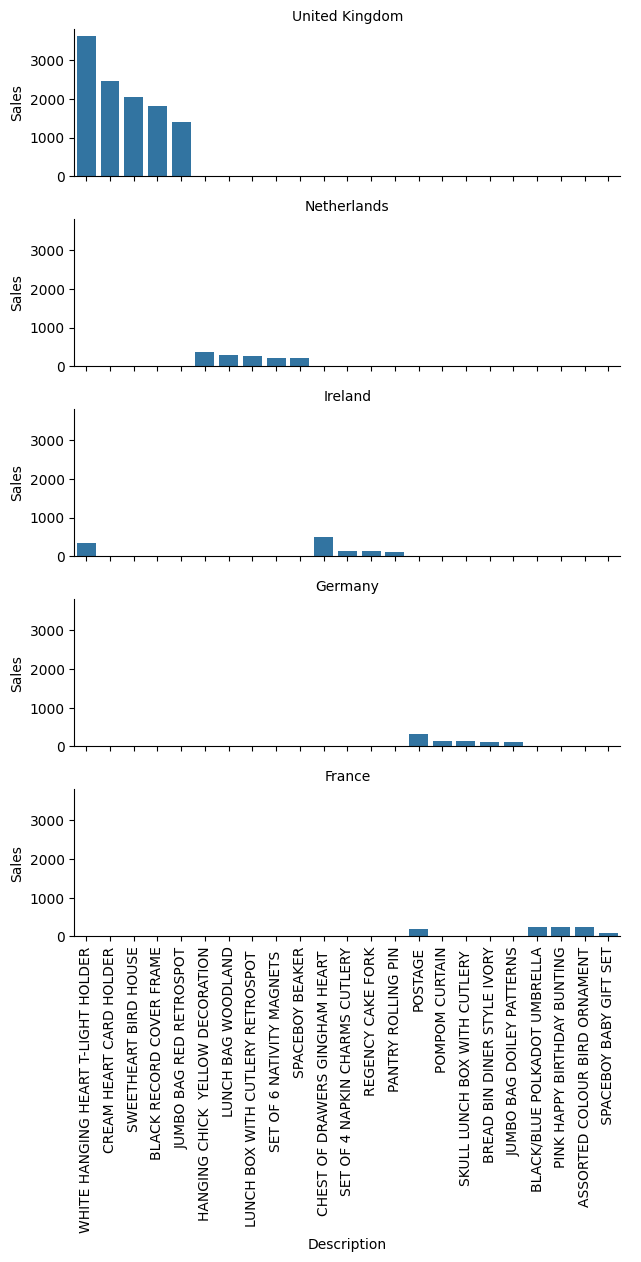

In [41]:
# Create Faceted Bar Chart
g = sns.catplot(
    data=pop5,
    x= 'Description',
    y= 'Sales',
    row= 'Country',
    kind= 'bar',
    estimator = sum,
    height= 2,
    aspect = 3.5,
    sharey=True
)

g.set_titles('{row_name}')
plt.xticks(rotation=90)
plt.show()

**Conclusion 5:**

Five popular products among top 5 countries with the highest sales are varied, but there are two countries that have the same interest on the same products such as:
1. *White Hanging Heart T-Light Holder* is popular among the British and Irish customers, with UK dominated the revenue from this product. Both countries shared tea culture where tea light usually purchased for this kind of occassion.  
2. *Postage* has popular sales in both Germany and France. This indicates that postal collections and snail mail are still popular among people from respective countries.
